In [1]:
import os
import opendatasets as od
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder,RobustScaler,StandardScaler
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

In [2]:
od.download("https://www.kaggle.com/datasets/dhruvb2028/student-academic-performance-dataset-for-ml/data")

Skipping, found downloaded files in ".\student-academic-performance-dataset-for-ml" (use force=True to force download)


In [3]:
std=pd.read_csv(r"student-academic-performance-dataset-for-ml/Students_Performance_dataset.csv")

In [4]:
std.head()

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


# Data Understanding

In [5]:
std.shape

(1194, 31)

In [6]:
std.isna().sum()

University Admission year                                                    0
Gender                                                                       0
Age                                                                          0
H.S.C passing year                                                           0
Program                                                                      0
Current Semester                                                             0
Do you have meritorious scholarship ?                                        0
Do you use University transportation?                                        0
How many hour do you study daily?                                            0
How many times do you seat for study in a day?                               0
What is your preferable learning mode?                                       0
Do you use smart phone?                                                      0
Do you have personal Computer?                      

In [7]:
std.duplicated().sum()

np.int64(0)

In [8]:
std.dtypes

University Admission year                                                      int64
Gender                                                                        object
Age                                                                            int64
H.S.C passing year                                                             int64
Program                                                                       object
Current Semester                                                               int64
Do you have meritorious scholarship ?                                         object
Do you use University transportation?                                         object
How many hour do you study daily?                                              int64
How many times do you seat for study in a day?                                 int64
What is your preferable learning mode?                                        object
Do you use smart phone?                                          

# EDA

In [9]:
std['Age'].value_counts()

Age
20    352
21    295
22    213
23    109
19     81
24     69
25     58
26     12
18      4
27      1
Name: count, dtype: int64

In [10]:
std['Do you have meritorious scholarship ?'].value_counts()

Do you have meritorious scholarship ?
No     671
Yes    523
Name: count, dtype: int64

In [11]:
le=LabelEncoder()

In [12]:
std['Do you have meritorious scholarship ?']=le.fit_transform(std['Do you have meritorious scholarship ?'])

In [13]:
for i in std.columns[7:32]:
    print("the unique",std[i].unique())
    print(std[i].value_counts())
    print("="*75)

the unique ['No' 'Yes']
Do you use University transportation?
No     697
Yes    497
Name: count, dtype: int64
the unique [ 3  1  2  5  6  4  8  7  9  0 10 13]
How many hour do you study daily?
2     315
3     307
4     181
1     156
5     124
6      61
7      19
8      15
0       9
9       4
10      2
13      1
Name: count, dtype: int64
the unique [2 3 1 4 5 7 0 6]
How many times do you seat for study in a day?
2    563
1    372
3    211
4     29
5     10
0      6
7      2
6      1
Name: count, dtype: int64
the unique ['Offline' 'Online']
What is your preferable learning mode?
Offline    858
Online     336
Name: count, dtype: int64
the unique ['Yes' 'No']
Do you use smart phone?
Yes    1178
No       16
Name: count, dtype: int64
the unique ['Yes' 'No']
Do you have personal Computer?
Yes    1095
No       99
Name: count, dtype: int64
the unique [ 5  3  2  1  4  6  7  8 15 10 12  0 20 16 11  9]
How many hour do you spent daily in social media?
2     348
3     289
1     194
4     112
5     

In [14]:
for i in std.columns[7:28]:
    if std[i].dtypes==int:
        continue
    elif ((i=="What are the skills do you have ?") or (i=="What is you interested area?") or i==('Do you have any health issues?')):
        continue
    else:
        std[i]=le.fit_transform(std[i])

In [15]:
std.dtypes

University Admission year                                                      int64
Gender                                                                        object
Age                                                                            int64
H.S.C passing year                                                             int64
Program                                                                       object
Current Semester                                                               int64
Do you have meritorious scholarship ?                                          int64
Do you use University transportation?                                          int64
How many hour do you study daily?                                              int64
How many times do you seat for study in a day?                                 int64
What is your preferable learning mode?                                         int64
Do you use smart phone?                                          

In [16]:
std["Do you have any health issues?"] = std["Do you have any health issues?"].str.lower().map({"no": 0, "Yes": 1,"No":0,'N':0})

In [17]:
std['Do you have any health issues?']=std['Do you have any health issues?'].fillna(1)

In [18]:
std.head()

,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,1,0,3,2,...,Data Schince,4,1,0,0.0,128,0,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,1,1,3,2,...,Event management,4,1,1,0.0,128,0,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,0,0,3,3,...,Software,4,0,0,0.0,128,0,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,1,0,1,3,...,Artificial Intelligence,4,0,0,1.0,128,0,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,1,0,3,1,...,Software,3,0,0,1.0,128,0,3.15,36,50000


# Data Visualization

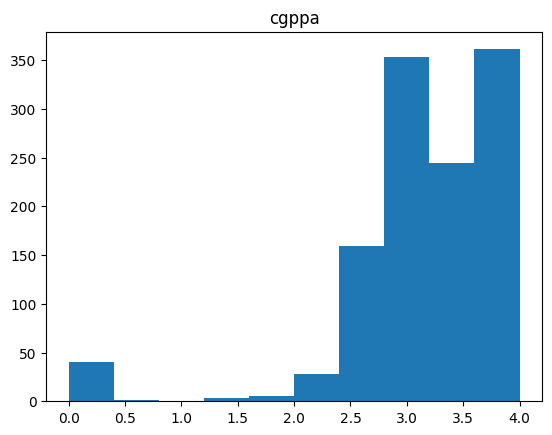

In [19]:
plt.hist(std['What is your current CGPA?'])
plt.title("cgppa")
plt.show()

In [20]:
x=std.drop(['What is you interested area?','What are the skills do you have ?','University Admission year','Gender','H.S.C passing year','Program'],axis=1)

In [21]:
x.shape

(1194, 25)

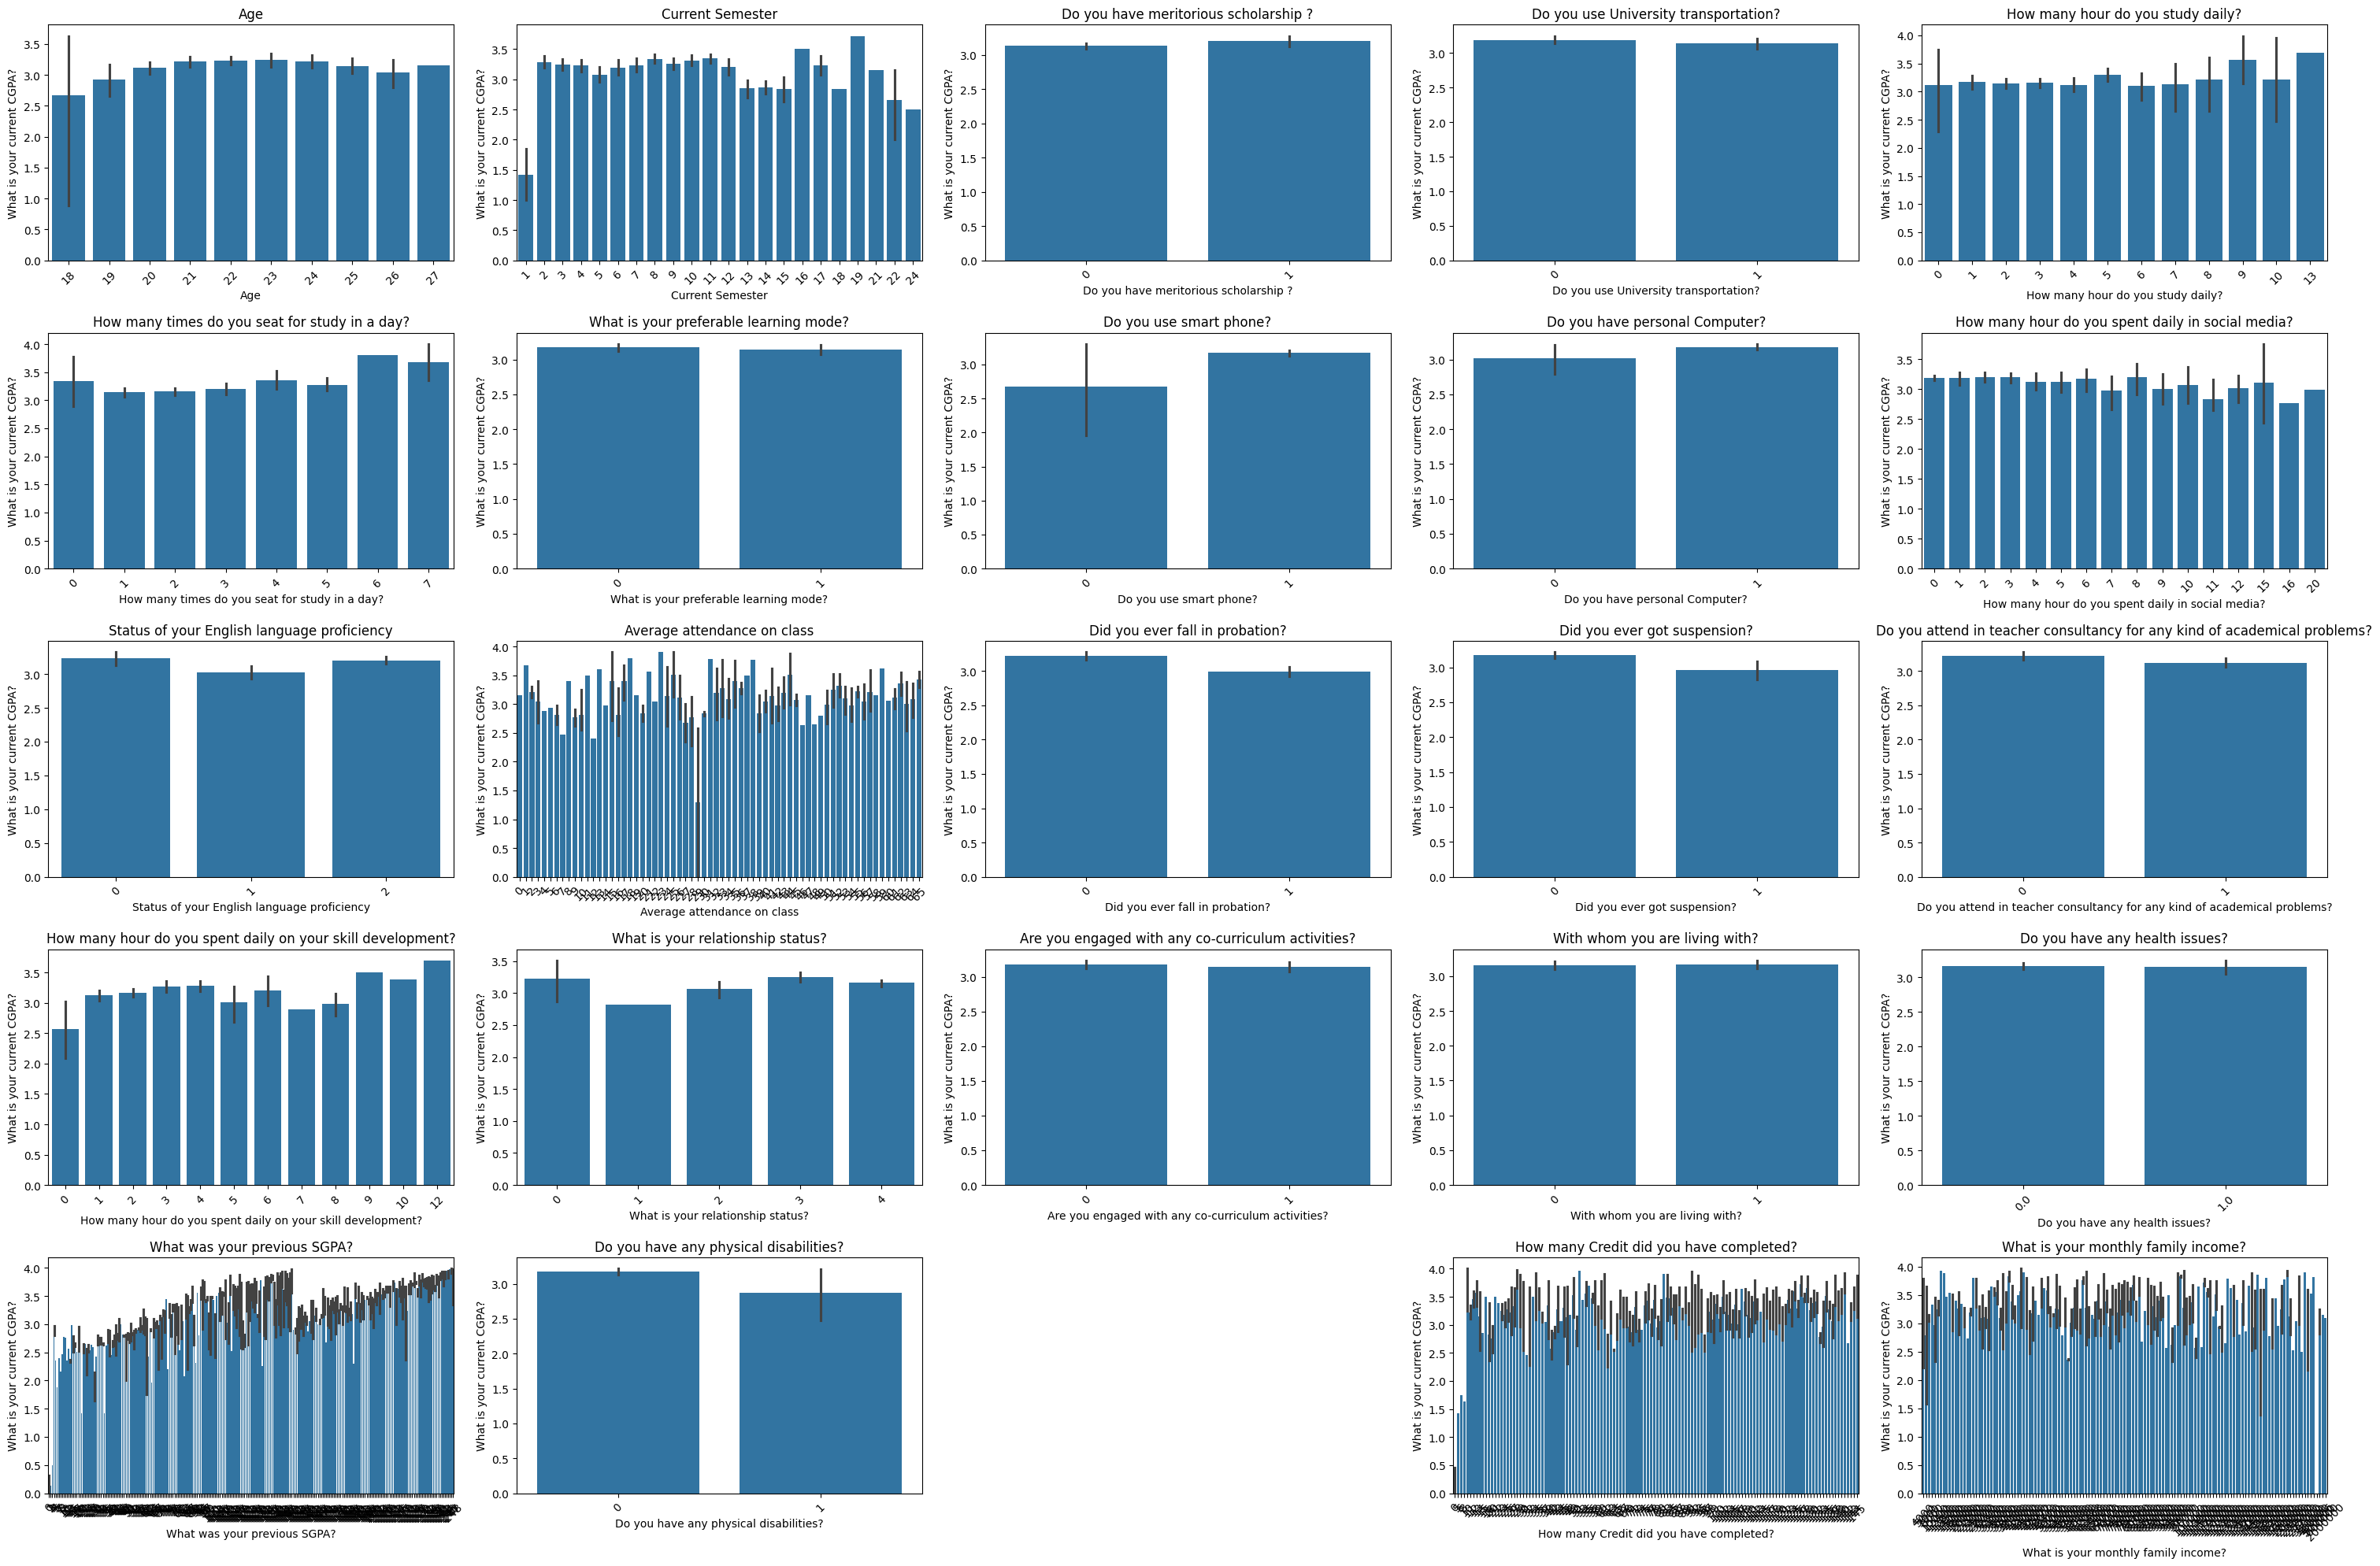

In [22]:
cols = x.columns
target = 'What is your current CGPA?'  # make sure exact name

fig, axes = plt.subplots(5, 5, figsize=(30, 20))
axes = axes.flatten()

for i, col in enumerate(cols[:25]):
    if col != target:
        sns.barplot(data=std, x=col, y=target, ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].axis("off")

plt.tight_layout()
plt.show()

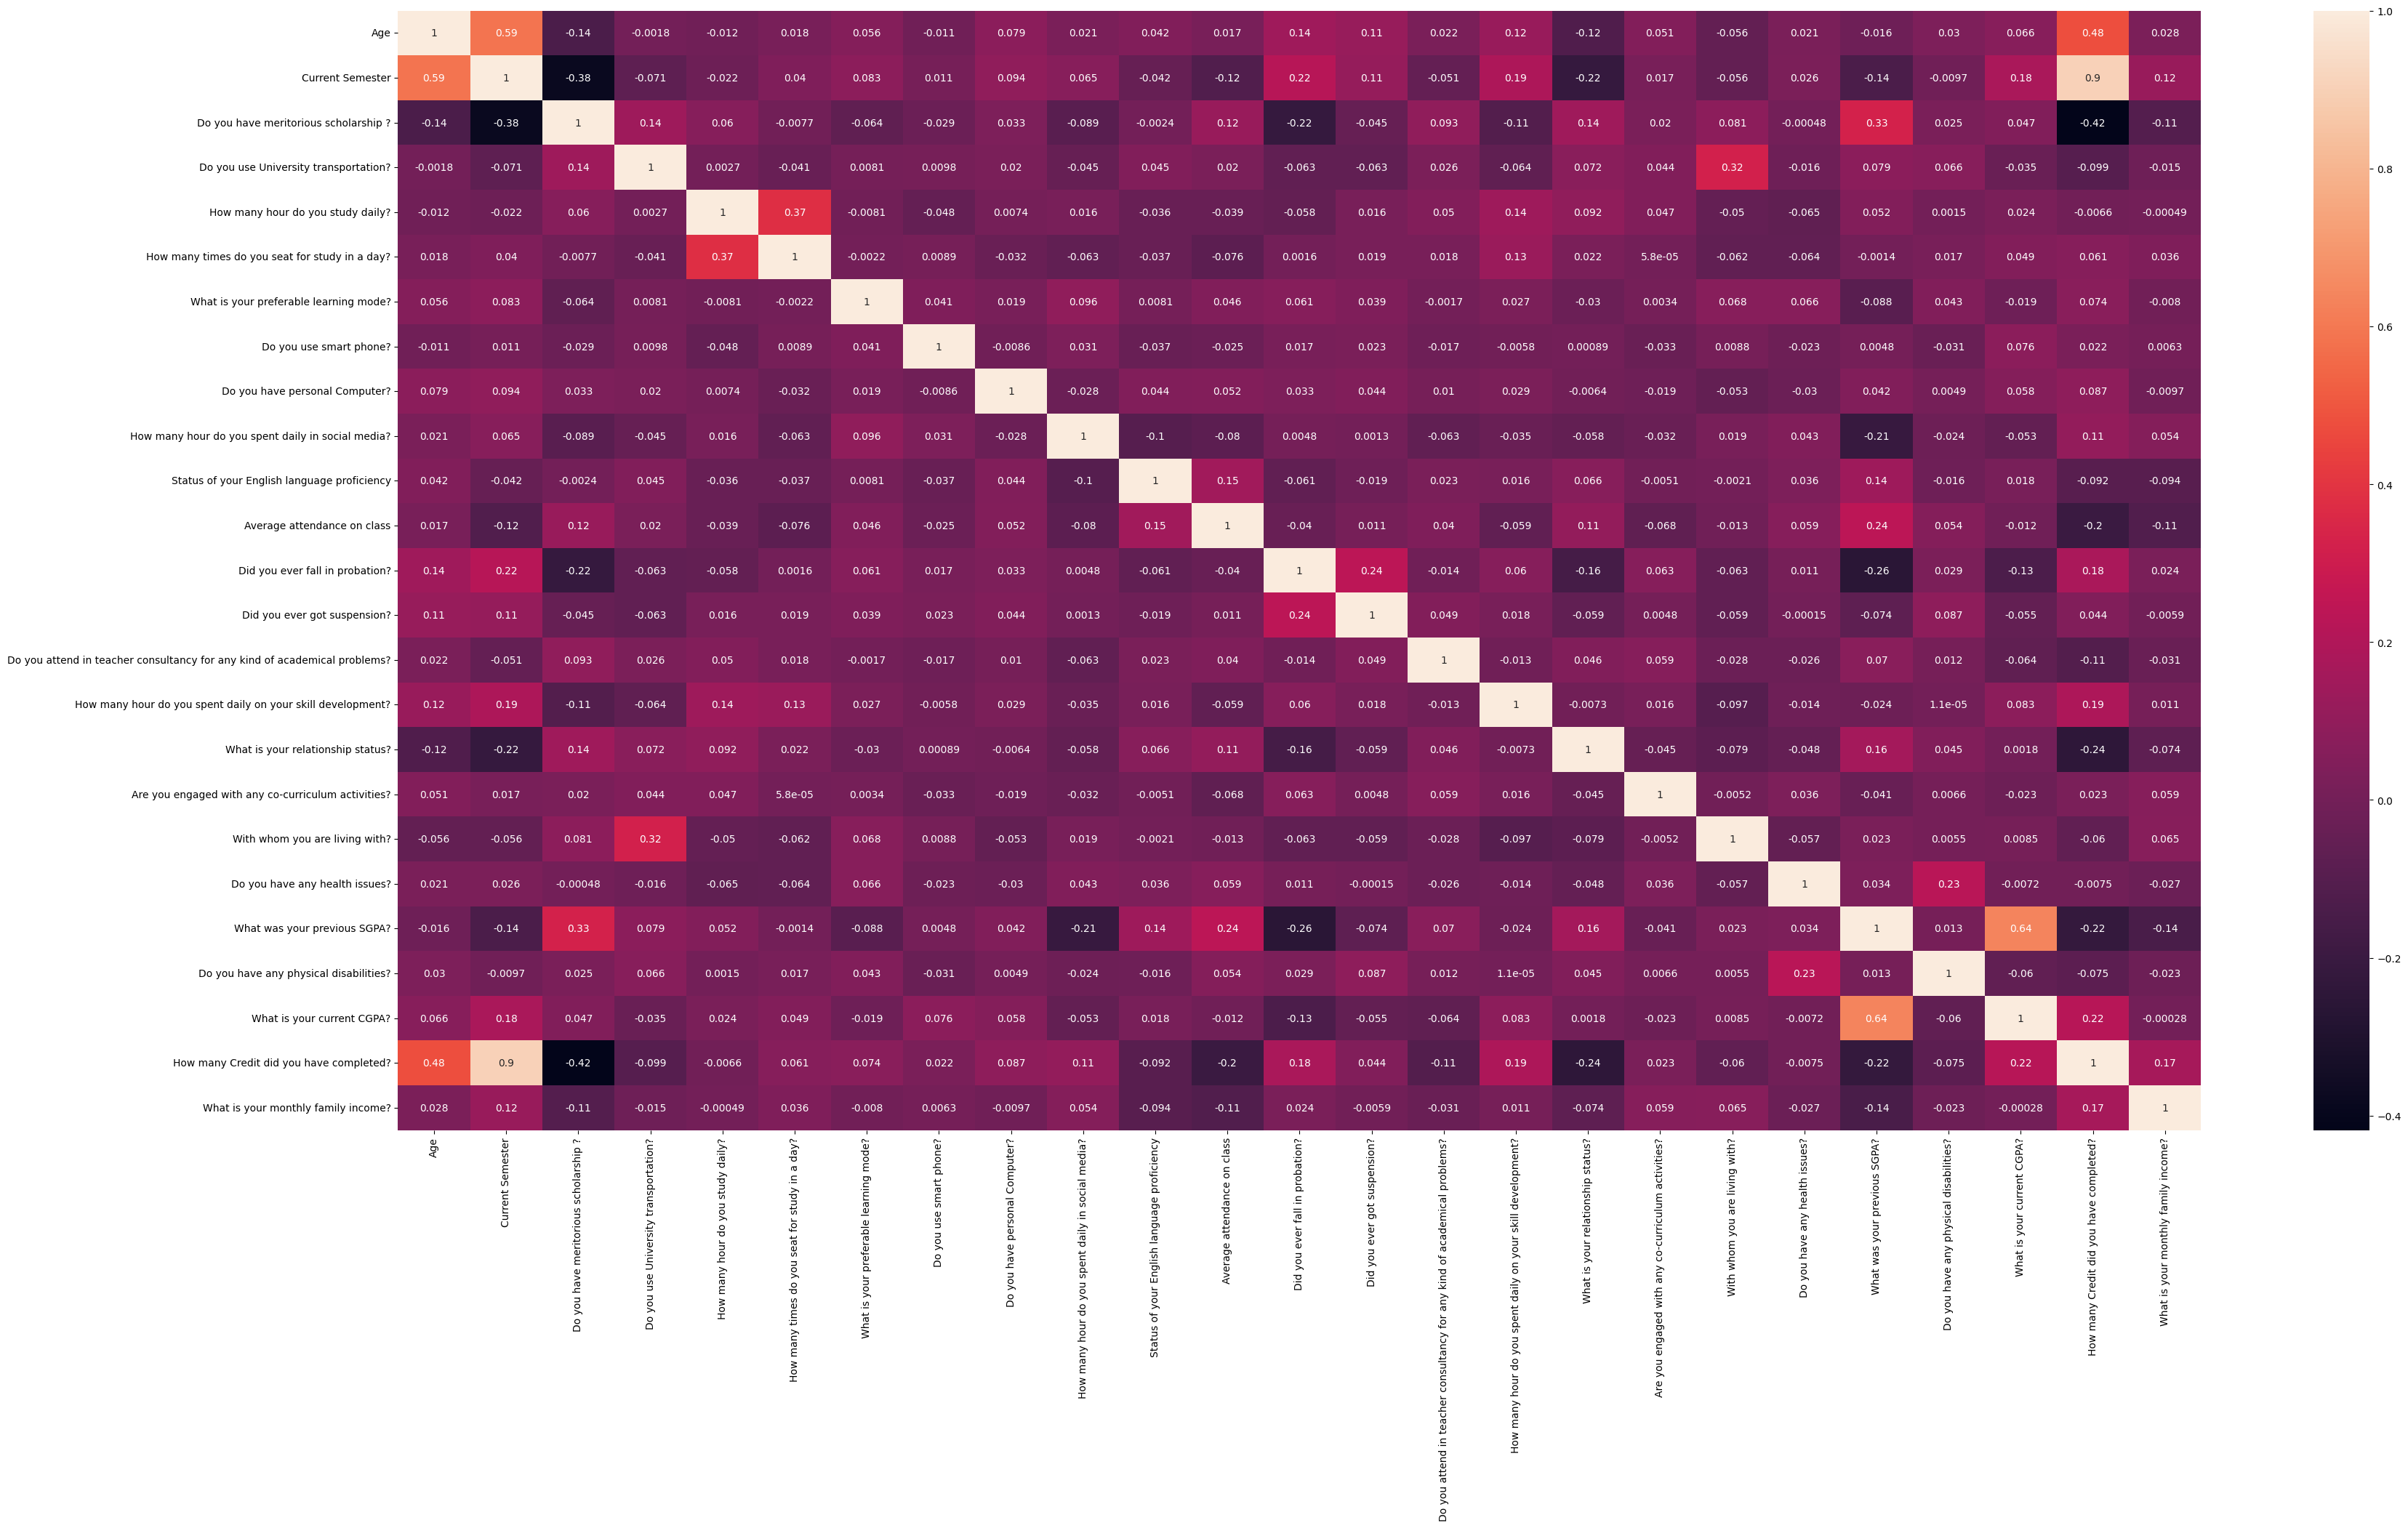

In [23]:
plt.figure(figsize=(40,20))
sns.heatmap(x.corr(),annot=True)
plt.show()

In [24]:
std['What is your current CGPA?'] = std['What is your current CGPA?'].apply(lambda x: 'High' if x >= std['What is your current CGPA?'].median() else 'Low')

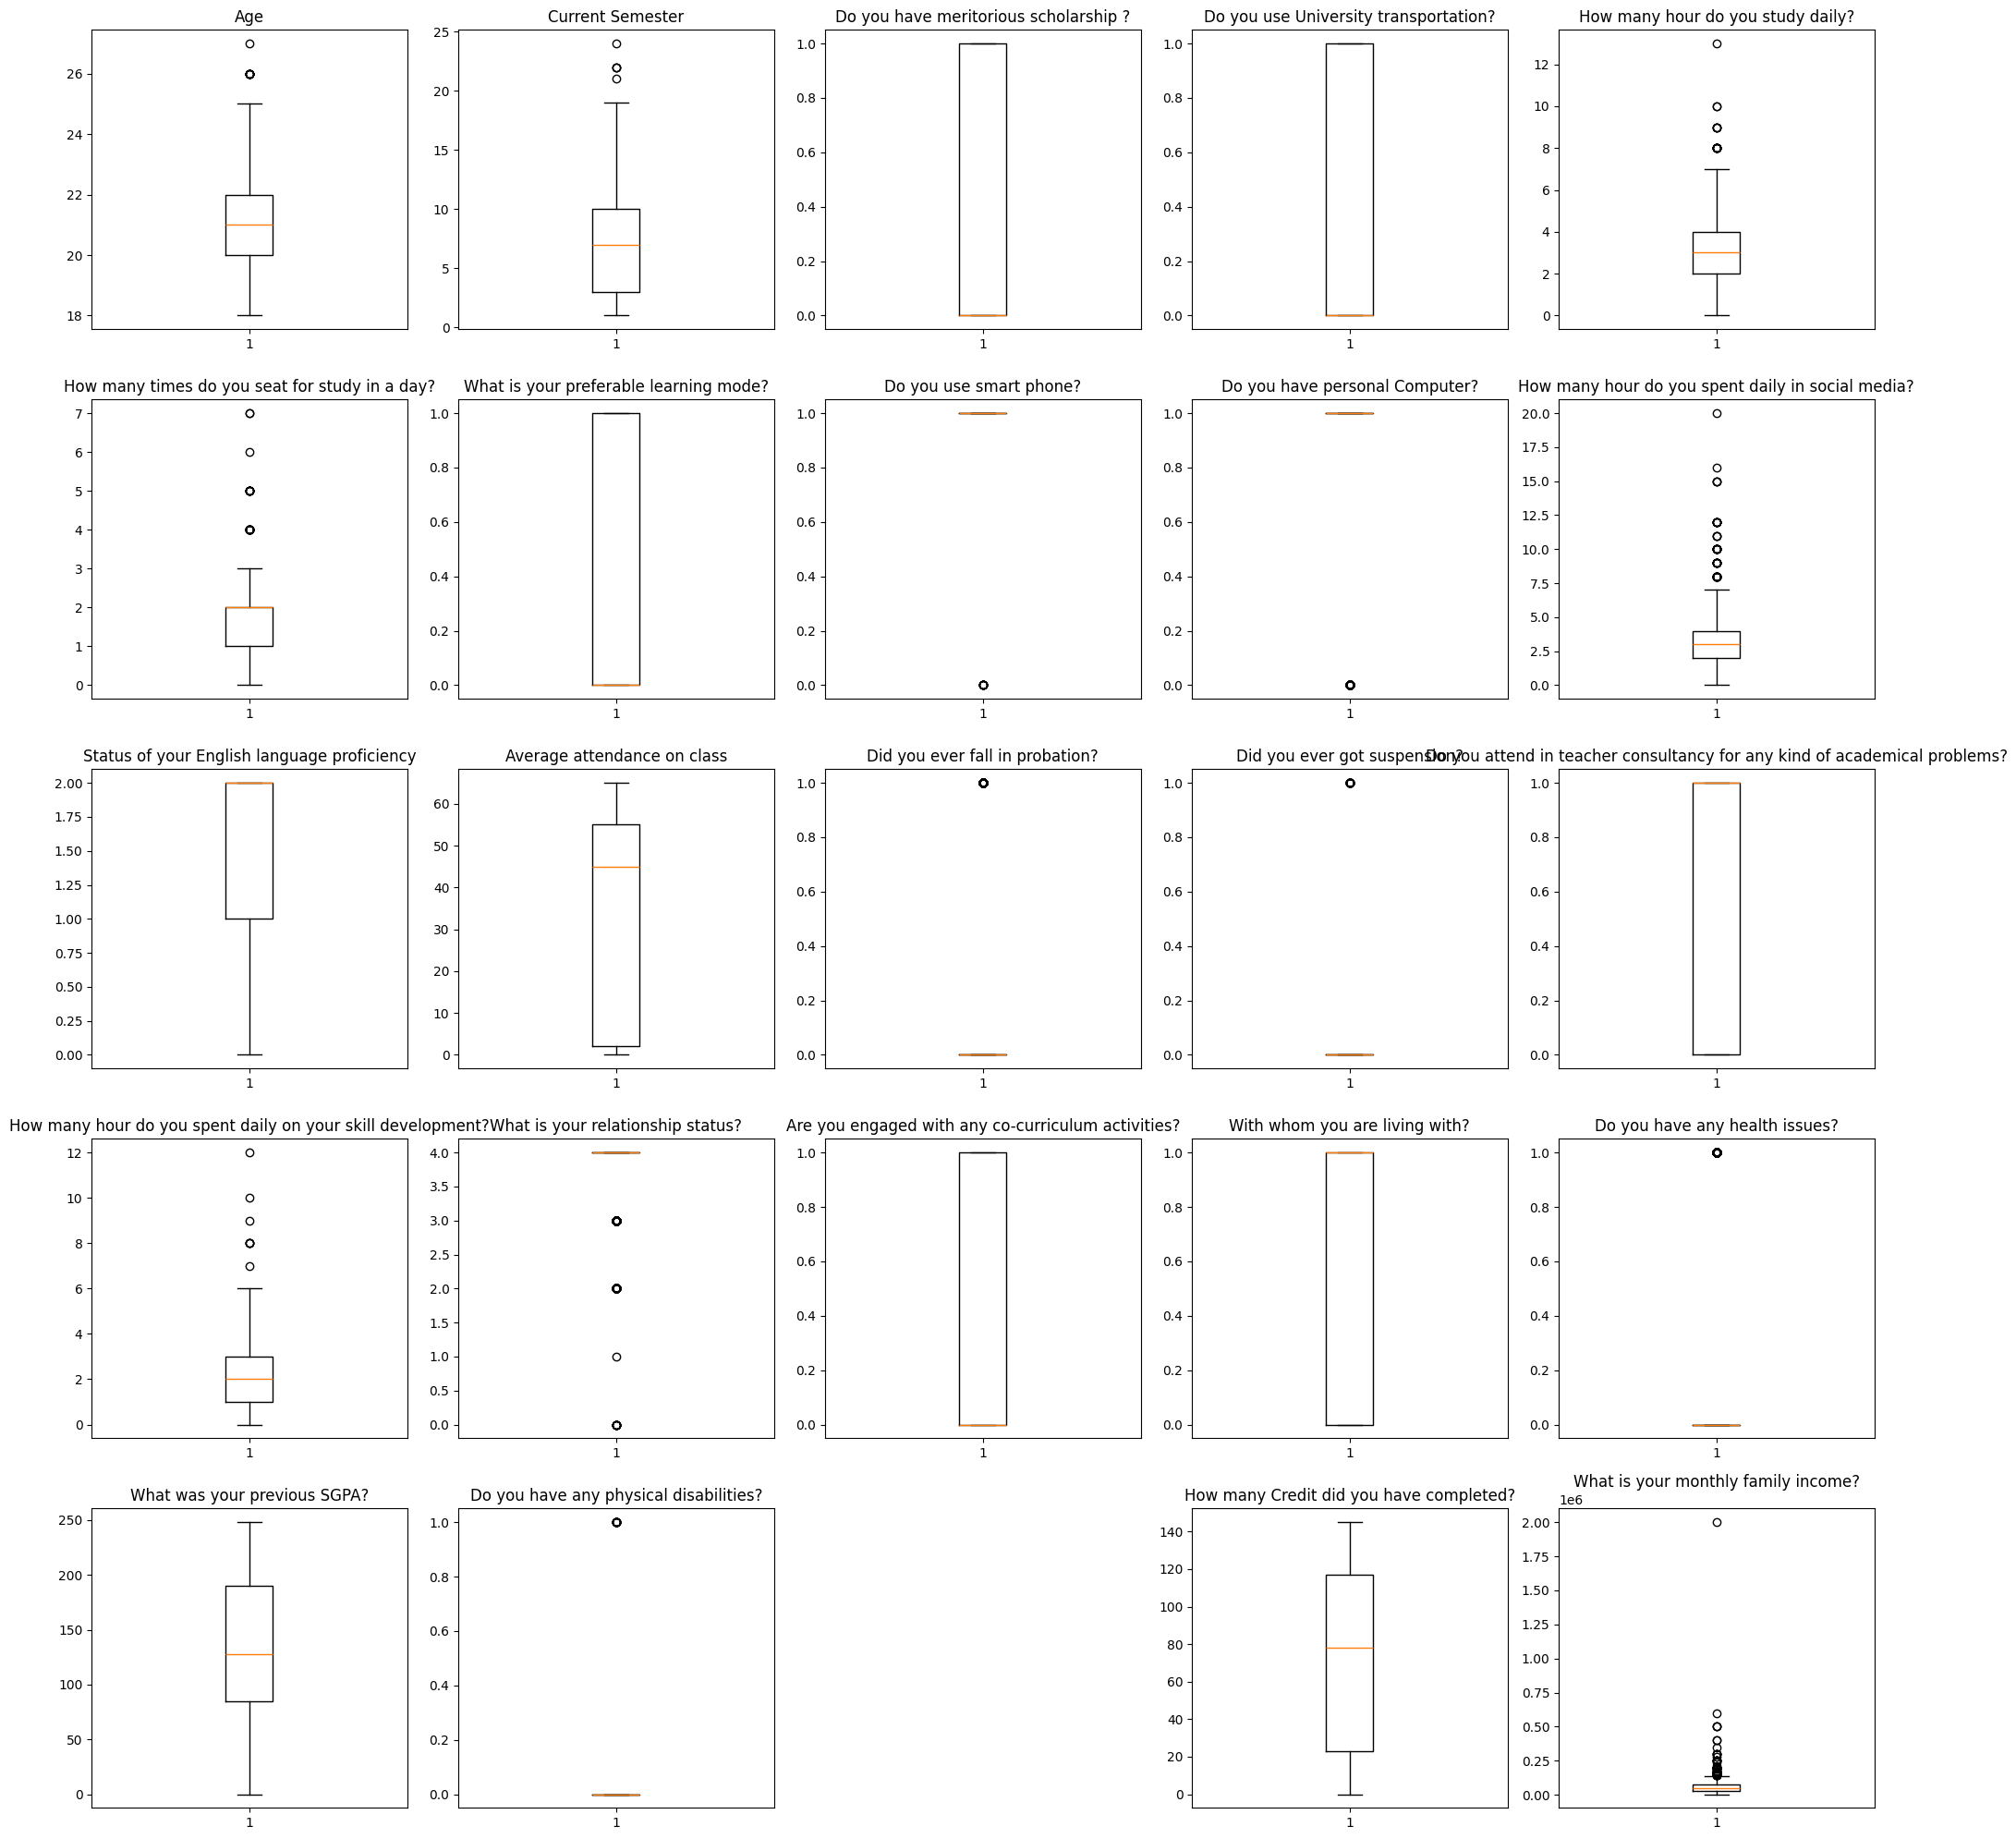

In [25]:
cols = x.columns
target = "What is your current CGPA?"

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols[:25]):
    if col != target:
        axes[i].boxplot(x[col])
        axes[i].set_title(col)
    else:
        axes[i].axis("off")

plt.tight_layout()
plt.show()

In [26]:
print("Age")
print("Mean",std['Age'].mean())
print("Medaian",std['Age'].median())
print("Min",std['Age'].min())
print("Max",std['Age'].max())
print(std['Age'].dtypes)

Age
Mean 21.343383584589613
Medaian 21.0
Min 18
Max 27
int64


In [27]:
(std['Age']>25).sum()

np.int64(13)

In [28]:
std.loc[std['Age']>25,'Age']=21

In [29]:
sc=StandardScaler()

In [30]:
std['What is your current CGPA?']=le.fit_transform(std['What is your current CGPA?'])

In [31]:
m=['How many hour do you study daily?','How many times do you seat for study in a day?','How many hour do you spent daily in social media?','How many hour do you spent daily on your skill development?']
for i in m:
    std[i]=sc.fit_transform(std[[i]])

# Model Training

In [32]:
features=std.drop(['What is your monthly family income?','Do you use University transportation?','What is your relationship status?','With whom you are living with?','What is your current CGPA?','Gender','What are the skills do you have ?','Current Semester','University Admission year','Program','What is you interested area?','What are the skills do you have ?'],axis=1)
target=std['What is your current CGPA?']

In [33]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.20,random_state=42)

In [34]:
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [35]:
lr=LogisticRegression(max_iter=10000)

In [36]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [37]:
pre_train=lr.predict(x_train)
acc_train=accuracy_score(y_train,pre_train)
print("Training SCore",acc_train)

Training SCore 0.856544502617801


In [38]:
pre_test=lr.predict(x_test)
acc_test=accuracy_score(y_test,pre_test)
print("Test SCore",acc_test)

Test SCore 0.8493723849372385


# Model Evaluation 

In [39]:
f1_test=f1_score(y_test,pre_test)
print("Test SCore of F1",f1_test)

Test SCore of F1 0.8448275862068966


In [40]:
cm_train=confusion_matrix(y_train,pre_train)
print("Train SCore of Confusion Matrix",cm_train)

Train SCore of Confusion Matrix [[407  68]
 [ 69 411]]


In [41]:
cm_test=confusion_matrix(y_test,pre_test)
print("Test SCore of Confusion Matrix",cm_test)

Test SCore of Confusion Matrix [[105  18]
 [ 18  98]]


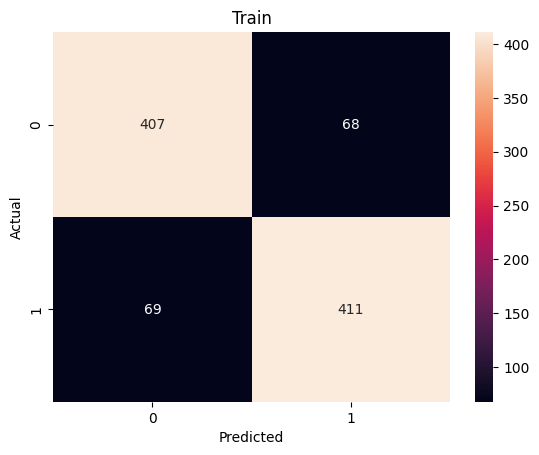

In [42]:
sns.heatmap(cm_train, annot=True, fmt="d")
plt.title("Train")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

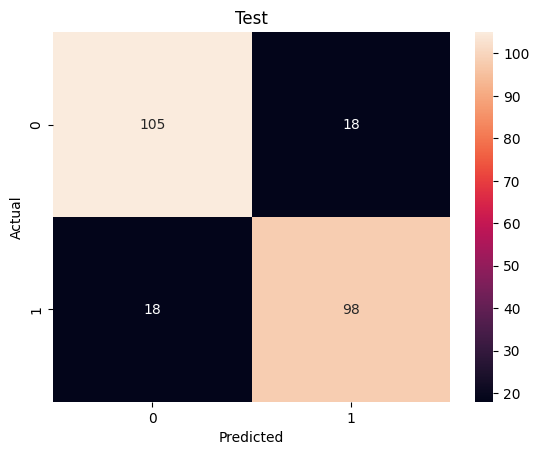

In [43]:
sns.heatmap(cm_test, annot=True, fmt="d")
plt.title("Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()